In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
import koreanize_matplotlib
from IPython.display import display
import math

In [2]:
# 워드클라우드
from wordcloud import WordCloud
from collections import Counter

# EDA

1. **제주도 관광지 전체 이미지** 도출 : 관광지 태그 빈도수 TOP 30, 워드클라우드 활용
2. **지역과 관광지 태그** 연계 : 지역별(ex.애월, 성산) 관광 테마 도출
3. **TF-IDF** : 가중치 높은 태그 확인을 통해 지역별 관광지 특성 구체화 // 가중치 있는 태그 우선 표시에 활용

# 1. 데이터 로드

In [3]:
da = pd.read_csv('10_visit_jeju_c1_tag_final_cleaned_for_da.csv', encoding='utf-8')
df = pd.DataFrame(da)
df.head(3)

,contentsid,title,roadaddress,introduction,latitude,longitude,phoneno,region1cd_value,region1cd_label,region2cd_value,region2cd_label,repPhoto_descseo,repPhoto_photoid_photoid,repPhoto_photoid_imgpath,repPhoto_photoid_thumbnailpath,by_region_label,merged_tag_cleaned_for_da
0,CNTS_000000000019003,제주국제예술센터,제주특별자치도 서귀포시 대정읍 서삼중로 117,제주의 문화와 예술이 담긴 곳,33.271830,126.199440,010-4696-8799,region2,서귀포시,22,대정,제주국제예술센터,4131,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_서부,"예술,실내,미술,박물관,흐림,사계절,실내관광지,어트랙션"
1,CNTS_300000000012728,제주펫스쿨,제주특별자치도 서귀포시 대정읍 칠전로 438,“반려견과 보호자가 함께하는 올바른 반려문화를 만들어요.”\r\n 제주펫스쿨에서는 ...,33.286427,126.223154,0507-1365-4504,region2,서귀포시,22,대정,제주펫스쿨,2019022621770,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_서부,"반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험"
2,CNTS_300000000013522,샤카다이브,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1,제주 서귀포시에 위치한 다이빙샵 샤카다이브 입니다,33.325226,126.596193,010-2335-6446,region2,서귀포시,25,남원,샤카다이브,2019022651417,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_동부,"해양스포츠,스쿠버다이빙,체험다이빙,야간다이빙,자격증코스,펀다이빙,영어,실내,실외,체..."


In [4]:
df.columns

Index(['contentsid', 'title', 'roadaddress', 'introduction', 'latitude',
       'longitude', 'phoneno', 'region1cd_value', 'region1cd_label',
       'region2cd_value', 'region2cd_label', 'repPhoto_descseo',
       'repPhoto_photoid_photoid', 'repPhoto_photoid_imgpath',
       'repPhoto_photoid_thumbnailpath', 'by_region_label',
       'merged_tag_cleaned_for_da'],
      dtype='object')

* 분석에 사용할 칼럼 선택

In [5]:
df = df[['title', 'roadaddress', 'introduction', 'latitude',
       'longitude', 'phoneno', 'region2cd_label', 'by_region_label',
       'merged_tag_cleaned_for_da']]
df.head(3)

,title,roadaddress,introduction,latitude,longitude,phoneno,region2cd_label,by_region_label,merged_tag_cleaned_for_da
0,제주국제예술센터,제주특별자치도 서귀포시 대정읍 서삼중로 117,제주의 문화와 예술이 담긴 곳,33.271830,126.199440,010-4696-8799,대정,서귀포시_서부,"예술,실내,미술,박물관,흐림,사계절,실내관광지,어트랙션"
1,제주펫스쿨,제주특별자치도 서귀포시 대정읍 칠전로 438,“반려견과 보호자가 함께하는 올바른 반려문화를 만들어요.”\r\n 제주펫스쿨에서는 ...,33.286427,126.223154,0507-1365-4504,대정,서귀포시_서부,"반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험"
2,샤카다이브,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1,제주 서귀포시에 위치한 다이빙샵 샤카다이브 입니다,33.325226,126.596193,010-2335-6446,남원,서귀포시_동부,"해양스포츠,스쿠버다이빙,체험다이빙,야간다이빙,자격증코스,펀다이빙,영어,실내,실외,체..."


* 전처리 완료된 데이터

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      1341 non-null   object 
 1   roadaddress                1341 non-null   object 
 2   introduction               1341 non-null   object 
 3   latitude                   1341 non-null   float64
 4   longitude                  1341 non-null   float64
 5   phoneno                    1188 non-null   object 
 6   region2cd_label            1341 non-null   object 
 7   by_region_label            1341 non-null   object 
 8   merged_tag_cleaned_for_da  1341 non-null   object 
dtypes: float64(2), object(7)
memory usage: 94.4+ KB


In [7]:
df.shape

(1341, 9)

# 2. 데이터 분석

### 제주도 관광지 전체 이미지 도출

#### 1) 관광지 태그 top 30
    * 빈도수 기준 상위 30개 태그로 제주도 관광지의 특성을 살펴본다.

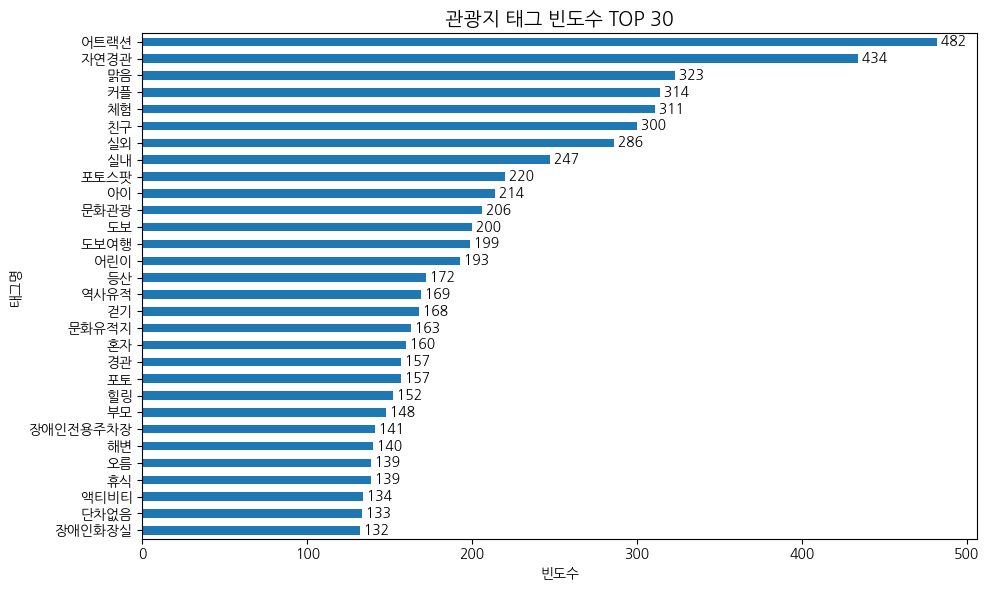

In [8]:
all_tags = ','.join(df['merged_tag_cleaned_for_da']).split(',')
tag_counts = pd.Series(all_tags).value_counts()
top30 = tag_counts.head(30)
plt.figure(figsize=(10,6))
top30.sort_values().plot(kind='barh')
for i, v in enumerate(top30.sort_values()):
    plt.text(v, i, f' {v}', va='center')
plt.title('관광지 태그 빈도수 TOP 30', fontsize=14)
plt.xlabel('빈도수')
plt.ylabel('태그명')
plt.tight_layout()
# plt.savefig('tag_top30.png', dpi=300, bbox_inches='tight')
plt.show()

#### [전체 해석]

* 어트랙션(관광명소) 태그가 482건으로 가장 많다.
* **자연경관, 맑음** 키워드가 각각 TOP2, TOP3로 제주도 특성상 **맑은날 자연경관을 볼 수 잇는 관광지가 가장 많은 것**으로 파악된다.
* **커플, 체험, 친구**는 각각 누구와 무엇을 하느냐와 관계된 키워드다. 제주도 관광지 중에서 커플이나 친구와 체험할 수 있는 관광지가 많음을 보여준다.
* **실외, 실내** 태그는 각각 약 300건에서 250건으로 **날씨에 따라 관광지 방문에 제약이 존재**함을 보여준다.
* 포토스팟과 하위에 위치한 포토를 합치면 약 300건 이상의 태그량을 보인다.
* **아이, 어린이** 태그도 합치면 407건의 태그량을 보여 **가족단위의 관광객을 위한 관광지**가 많음을 알 수 있다.
* **문화관광**이란 소비 중심 관광에서 벗어나 특정지역의 독특한 문화요소를 경험하는 관광을 일컫는다.
  약 200건 이상의 문화관광 태그는 제주도의 문화를 충분히 체험 할수있는 관광지가 200건 이상 됨을 보여준다.
* **도보, 도보여행, 걷기, 등산**는 각각 약 200건, 200건, 170건, 170건의 태그량을 보이며, 관광지 접근성보다는 **산책, 트레킹코스에 대한 태그로 해석**된다.
* **혼자** 태그는 전체 관광지 1341개에서 160건으로 약 12%를 차지한다.
* 태그 데이터를 보면 아이와 어린이를 합친 태그는 407건, 커플 314건, 친구 300건, 부모 148건 순이다.
  따라서 제주도는 가족단위 관광지가 가장 많다. 그 다음 커플, 친구, 부모님과 같이 가기 좋은 관광지가 많음을 알수 있다.
* **야외 관광지** 중 구체적으로 언급된 **주요 태그**는 **해변과 오름**이 있다. 
* **액티비티**는 134건으로 전체 관광지 1341개 중 약 10%를 차지한다.
* **무장애관광**과 관련해 제주도 관광지는 **장애인전용주차장, 단차없음, 장애인화장실**에 대한 태그량이 많은 것을 볼 수 있다.

#### [요약]

관광지 태그로 파악한 제주도 관광지의 특징을 요약하면 다음과 같다.

* 빈도수 상위 TOP10에 위치한 자연경관, 맑음 , 실외, 실내 태그는 제주도에 자연경관 관광지 수가 압도적으로 많음을 보여주며,                      
  동시에 날씨에 따른 관광제약요소가 존재함을 시사한다. 
* 동행인에 대한 태그로 아이, 어린이 태그가 407건의 태그량을 보여, 가족단위의 관광지가 가장 많다.
* 문화유적지, 문화관광 태그를 합치면 369건으로 제주도의 문화요소를 경험할 수 있는 관광지가 충분함을 보여준다.
* 도보, 도보여행, 걷기, 등산 태그는 총합 739건으로 산책, 트레킹코스가 풍부하다.
* 이와 관련 야외 관광지 중 구체적으로 언급된 주요태그는 오름과 해변이 있다.
* 특히 무장애관광에 대한 태그가 TOP30안에 위치해, 제주도 관광지의 Barrier-Free 지향성을 확인할 수 있다.

#### 2) 제주 전체 태그 워드 클라우드

In [9]:
# all_tags 아까 만든 태그 전체 리스트
all_tags = pd.Series(all_tags)
all_tags.value_counts().head(10)

어트랙션    482
자연경관    434
맑음      323
커플      314
체험      311
친구      300
실외      286
실내      247
포토스팟    220
아이      214
Name: count, dtype: int64

In [10]:
font_path = 'NanumBarunGothic.ttf'

wordcloud = WordCloud(
    font_path = font_path,
    width = 800,
    height = 800,
    background_color="white"
)

In [11]:
count = Counter(all_tags)
wordcloud = wordcloud.generate_from_frequencies(count)

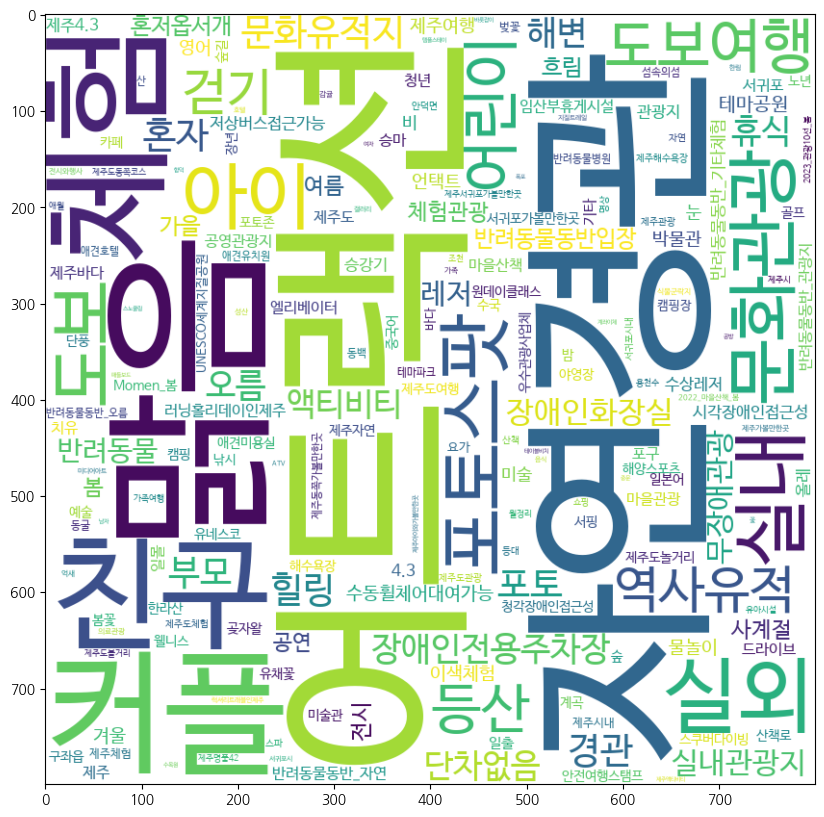

In [12]:
def __array__(self):
    """Convert to numpy array.
    Returns
    -------
    image : nd-array size (width, height, 3)
        Word cloud image as numpy matrix.
    """
    return self.to_array()

def to_array(self):
    """Convert to numpy array.
    Returns
    -------
    image : nd-array size (width, height, 3)
        Word cloud image as numpy matrix.
    """
    return np.array(self.to_image())
array = wordcloud.to_array()

fig = plt.figure(figsize=(10, 10))
plt.imshow(array, interpolation="bilinear")
# plt.savefig('wordcloud1.png', dpi=300, bbox_inches='tight')
plt.show()


mask 변환 방식1


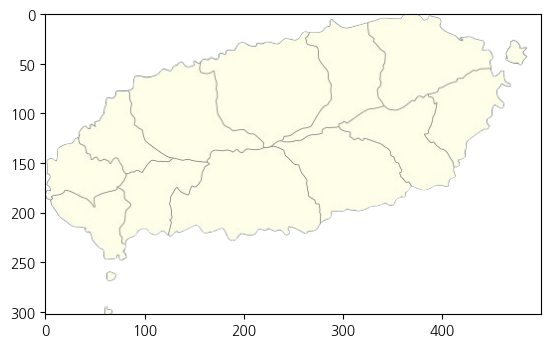

In [13]:
from PIL import Image
import numpy as np
from wordcloud import ImageColorGenerator

image_name = 'jeju.png'


target_image = Image.open(image_name) 

try:
    mask = Image.new("RGB", target_image.size, (255,255,255))
    mask.paste(target_image,target_image)
    mask = np.array(mask)
    print("mask 변환 방식1")
except:
    print(image_name)
    mask=np.array(Image.open(image_name))
    print("mask 변환 방식2")
finally:
    plt.imshow(target_image)

In [14]:
count = Counter(all_tags)

wc_jeju_whole = WordCloud(
    font_path = font_path,
    # mask=moon_mask,
    mask=mask,
    background_color="white"
)

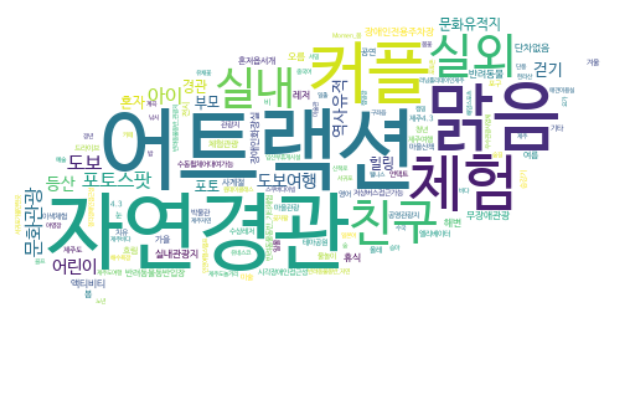

In [15]:
wc_jeju_whole = wc_jeju_whole.generate_from_frequencies(count)

plt.figure(figsize=(8,8))
plt.imshow(wc_jeju_whole,interpolation="bilinear")
plt.axis("off")
# plt.savefig('wordcloud2.png', dpi=300, bbox_inches='tight')
plt.show()

###  지역별(ex.애월, 성산) 관광 태그로 관광 테마 도출

* group_by로 지역별 관광 태그 빈도수 TOP 10 확인
* 지역별 TOP10 태그는 전체 TOP30 태그 분포와 유사한 양상
* 따라서 지역별 각 태그 순위와 해당 지역에만 존재하는 특이한 태그를 함께 고려하여 관광지 특성을 파악
* 다만, 특이 태그가 지역 관광지 특성을 대표하는 것은 아님에 유의

In [16]:
df.columns

Index(['title', 'roadaddress', 'introduction', 'latitude', 'longitude',
       'phoneno', 'region2cd_label', 'by_region_label',
       'merged_tag_cleaned_for_da'],
      dtype='object')

* 지역 확인

In [17]:
df['region2cd_label'].value_counts()

region2cd_label
제주시내     261
서귀포시내    178
구좌       113
애월       109
조천       105
안덕        99
한림        72
성산        70
남원        66
대정        60
한경        58
표선        52
중문        39
추자도       26
우도        22
마라도        6
비양도        2
가파도        2
차귀도        1
Name: count, dtype: int64

In [18]:
df['all_tags'] = df['merged_tag_cleaned_for_da'].str.split(',')

df_exploded = df.explode('all_tags')

tag_counts_by_region = (
    df_exploded
    .groupby('region2cd_label')['all_tags'] 
    .value_counts() 
    .reset_index(name='count')  
    .sort_values(['region2cd_label', 'count'], ascending=[True, False])
)

In [19]:
top10_by_region = (
    tag_counts_by_region
    .groupby('region2cd_label')
    .head(10)
)

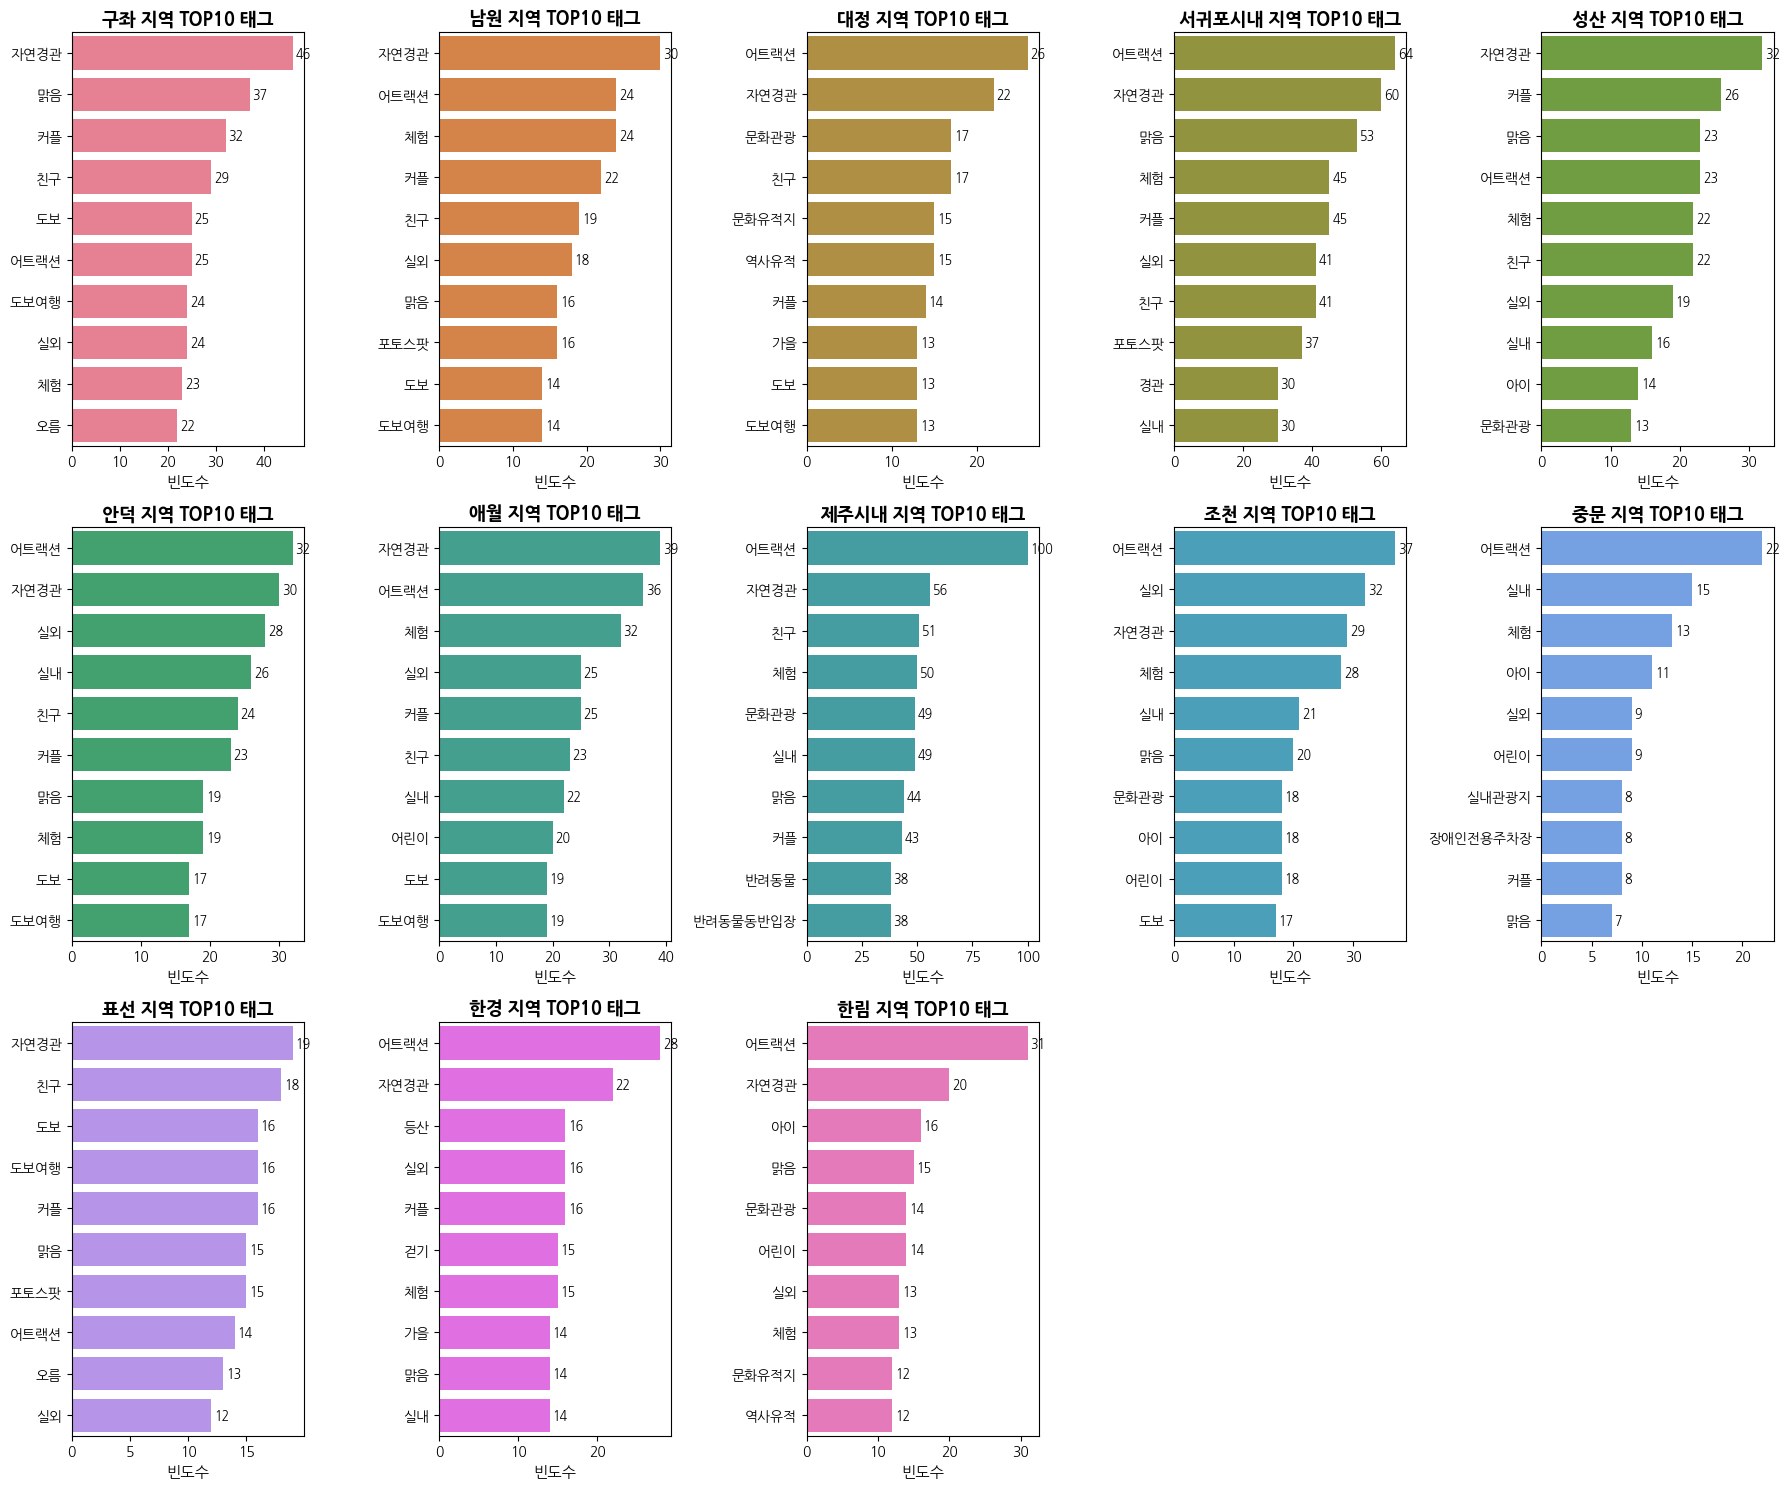

In [20]:
# 섬 지역 제외 (이유 : 적은 태그량)
exclude_regions = ['비양도', '차귀도', '가파도', '추자도', '우도', '마라도']

# 필터링된 지역 목록
regions = [r for r in top10_by_region['region2cd_label'].unique() if r not in exclude_regions]
n_regions = len(regions)

cols = 5
rows = math.ceil(n_regions / cols)

region_palettes = sns.color_palette("husl", n_regions)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

# 지역별 bar chart 그리기
for i, region_name in enumerate(regions):
    df_plot = top10_by_region[top10_by_region['region2cd_label'] == region_name]
    df_plot = df_plot.sort_values('count', ascending=False)

    sns.barplot(
        x='count',
        y='all_tags',
        data=df_plot,
        ax=axes[i],
        color=region_palettes[i]
    )

    axes[i].set_title(f'{region_name} 지역 TOP10 태그', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('빈도수', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=10)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=2)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
# plt.savefig('top10_by_region.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
region_name = '제주시내' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
1842,제주시내,어트랙션,100
1843,제주시내,자연경관,56
1844,제주시내,친구,51
1845,제주시내,체험,50
1846,제주시내,문화관광,49
1847,제주시내,실내,49
1848,제주시내,맑음,44
1849,제주시내,커플,43
1850,제주시내,반려동물,38
1851,제주시내,반려동물동반입장,38


In [22]:
# 제주 시내에 반려동물 키워드가 상대적으로 많은 이유는 동물병원, 애견카페, 애견호텔과 같은 장소가 많기 때문이다.
# 하지만 이를 제주 시내 관광지의 전체 특성으로 보긴 어렵다.
# 자연경관, 문화관광 키워드가 모두 존재해 자연감상 및 문화체험, 실내 관광을 같이 할 수 있는 지역이다.

In [23]:
region_name = '서귀포시내' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
684,서귀포시내,어트랙션,64
685,서귀포시내,자연경관,60
686,서귀포시내,맑음,53
687,서귀포시내,체험,45
688,서귀포시내,커플,45
689,서귀포시내,실외,41
690,서귀포시내,친구,41
691,서귀포시내,포토스팟,37
692,서귀포시내,경관,30
693,서귀포시내,실내,30


In [24]:
# 서귀포 시내는 실내 보다 날씨가 맑을 때 가기 좋은 실외, 자연경관 관광지 위주이다.

In [25]:
region_name = '구좌' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
18,구좌,자연경관,46
19,구좌,맑음,37
20,구좌,커플,32
21,구좌,친구,29
22,구좌,도보,25
23,구좌,어트랙션,25
24,구좌,도보여행,24
25,구좌,실외,24
26,구좌,체험,23
27,구좌,오름,22


In [26]:
# 구좌는 도보, 도보여행, 실외, 오름에 대한 태그를 통해 트레킹 테마를 도출할 수 있다. 

In [27]:
region_name = '애월'  
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
1499,애월,자연경관,39
1500,애월,어트랙션,36
1501,애월,체험,32
1502,애월,실외,25
1503,애월,커플,25
1504,애월,친구,23
1505,애월,실내,22
1506,애월,어린이,20
1507,애월,도보,19
1508,애월,도보여행,19


In [28]:
# 애월은 커플, 친구, 어린이 태그가 모두 존재해 동행인과 상관 없이 누구든 여행하기 좋은 지역으로 추정된다.
# 체험, 자연경관, 도보등 다양한 관광요소가 어우러진 곳이다.

In [29]:
region_name = '조천' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2286,조천,어트랙션,37
2287,조천,실외,32
2288,조천,자연경관,29
2289,조천,체험,28
2290,조천,실내,21
2291,조천,맑음,20
2292,조천,문화관광,18
2293,조천,아이,18
2294,조천,어린이,18
2295,조천,도보,17


In [30]:
# 조천은 자연경관, 실외, 실내, 문화관광, 아이,어린이, 도보 등  날씨에 구애 받지 않는 자연, 문화, 트레킹 등 다양한 요소가 분포되어 있다.
# 아이, 어린이 태그를 포함해 가족단위로 가기 좋은 관광지역이다. 

In [31]:
region_name = '안덕' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
1236,안덕,어트랙션,32
1237,안덕,자연경관,30
1238,안덕,실외,28
1239,안덕,실내,26
1240,안덕,친구,24
1241,안덕,커플,23
1242,안덕,맑음,19
1243,안덕,체험,19
1244,안덕,도보,17
1245,안덕,도보여행,17


In [32]:
# 안덕은 실내, 실외 관광지의 비중이 비슷한편으로 비교적 날씨 구애받지 않고 관광하기 좋은 편임을 알 수 있다. 

In [33]:
region_name = '한림' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
3172,한림,어트랙션,31
3173,한림,자연경관,20
3174,한림,아이,16
3175,한림,맑음,15
3176,한림,문화관광,14
3177,한림,어린이,14
3178,한림,실외,13
3179,한림,체험,13
3180,한림,문화유적지,12
3181,한림,역사유적,12


In [34]:
# 한림은 문화관광, 문화유적지, 역사유적이 주요 태그로 가족단위 관광객이 가기 좋은 문화유적 탐방 테마를 도출할 수 있다. 

In [35]:
region_name = '성산' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
1046,성산,자연경관,32
1047,성산,커플,26
1048,성산,맑음,23
1049,성산,어트랙션,23
1050,성산,체험,22
1051,성산,친구,22
1052,성산,실외,19
1053,성산,실내,16
1054,성산,아이,14
1055,성산,문화관광,13


In [36]:
# 성산은 타지역에 비해 자연경관과 커플 태그량이 높다. 
# 이는 커플 단위 관광객이 찾는 자연관광지가 주로 존재한다고 볼 수 있어, 신혼여행 관련 관광지역으로 추정할 수 있다.

In [37]:
region_name = '남원' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
281,남원,자연경관,30
282,남원,어트랙션,24
283,남원,체험,24
284,남원,커플,22
285,남원,친구,19
286,남원,실외,18
287,남원,맑음,16
288,남원,포토스팟,16
289,남원,도보,14
290,남원,도보여행,14


In [38]:
# 남원에서 타 지역과 다른 태그는 포토스팟이다. 사진찍기 좋은 관광지가 상대적으로 많음을 유추할 수 있다.

In [39]:
region_name = '대정'  
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
492,대정,어트랙션,26
493,대정,자연경관,22
494,대정,문화관광,17
495,대정,친구,17
496,대정,문화유적지,15
497,대정,역사유적,15
498,대정,커플,14
499,대정,가을,13
500,대정,도보,13
501,대정,도보여행,13


In [40]:
# 대정은 문화관광, 문화유적지, 역사유적의 태그량이 높아 제주 문화와 역사를 체험할 수 있는 지역일 것이다.
# 특히 가을철 대표 관광지를 포함하고 있을 가능성이 높다.

In [41]:
region_name = '한경' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2998,한경,어트랙션,28
2999,한경,자연경관,22
3000,한경,등산,16
3001,한경,실외,16
3002,한경,커플,16
3003,한경,걷기,15
3004,한경,체험,15
3005,한경,가을,14
3006,한경,맑음,14
3007,한경,실내,14


In [42]:
# 한경 지역의 주요 키워드는 등산, 걷기, 가을 이다. 계절 키워드가 들어가 상대적으로 가을에 트레킹 하기 좋은 관광지역이라는 주제를 도출할 수 있다.

In [43]:
region_name = '표선' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2806,표선,자연경관,19
2807,표선,친구,18
2808,표선,도보,16
2809,표선,도보여행,16
2810,표선,커플,16
2811,표선,맑음,15
2812,표선,포토스팟,15
2813,표선,어트랙션,14
2814,표선,오름,13
2815,표선,실외,12


In [44]:
# 표선은 도보, 도보여행, 오름이 있어 트레킹하기 좋은 지역일 것이다.
# 친구와 포토스팟 태그의 순위가 높아 친구와 사진 찍기 좋은 관광지 코스가 있음을 추정할 수 있다. 

In [45]:
region_name = '중문' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2596,중문,어트랙션,22
2597,중문,실내,15
2598,중문,체험,13
2599,중문,아이,11
2600,중문,실외,9
2601,중문,어린이,9
2602,중문,실내관광지,8
2603,중문,장애인전용주차장,8
2604,중문,커플,8
2605,중문,맑음,7


In [46]:
# 다른 지역은 실외 태그가 실내 태그보다 앞서는 형태를 보이는데  중문은 맑음 키워드도 하위권에 있어 실내 관광지 중심임을 알 수 있다.
# 또한 아이, 어린이 키워드가 포함되어 있어 가족단위 관광객에게 적합한 지역이다.

* 섬속의 섬들 태그 분석

In [47]:
# 추자도, 우도는 사진찍기 좋은 관광지 위주이다. 

In [48]:
region_name = '추자도' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2757,추자도,자연경관,12
2758,추자도,맑음,10
2759,추자도,포토스팟,10
2760,추자도,경관,9
2761,추자도,포토,9
2762,추자도,친구,8
2763,추자도,커플,8
2764,추자도,어트랙션,7
2765,추자도,가을,6
2766,추자도,걷기,6


In [49]:
region_name = '우도' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
1770,우도,맑음,15
1771,우도,포토스팟,11
1772,우도,자연경관,10
1773,우도,경관,9
1774,우도,체험,9
1775,우도,포토,9
1776,우도,어트랙션,8
1777,우도,커플,7
1778,우도,레저,6
1779,우도,액티비티,6


In [50]:
# 마라도, 가파도, 비양도, 차귀도는 관광지 태그량이 매우 적기 때문에, 특성을 파악하기에 의미있는 데이터라고 보기 어렵다.

In [51]:
region_name = '마라도'  
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
647,마라도,어트랙션,5
648,마라도,경관,3
649,마라도,부모,3
650,마라도,포토,3
651,마라도,포토스팟,3
652,마라도,가을,1
653,마라도,등대,1
654,마라도,마라도,1
655,마라도,맑음,1
656,마라도,문화관광,1


In [52]:
region_name = '비양도' 
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
668,비양도,UNESCO세계지질공원,1
669,비양도,경관,1
670,비양도,등대,1
671,비양도,맑음,1
672,비양도,봄,1
673,비양도,섬속의섬,1
674,비양도,유네스코,1
675,비양도,제주도서쪽코스,1
676,비양도,제주도여행,1
677,비양도,제주바다,1


In [53]:
region_name = '가파도'
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
0,가파도,봄,2
1,가파도,자연경관,2
2,가파도,친구,2
3,가파도,걷기,1
4,가파도,경관,1
5,가파도,도보,1
6,가파도,도보여행,1
7,가파도,등산,1
8,가파도,맑음,1
9,가파도,섬속의섬,1


In [54]:
region_name = '차귀도'  
top10_by_region[top10_by_region['region2cd_label'] == region_name]

,region2cd_label,all_tags,count
2747,차귀도,단풍,1
2748,차귀도,맑음,1
2749,차귀도,문화유적지,1
2750,차귀도,수월봉,1
2751,차귀도,언택트,1
2752,차귀도,역사유적,1
2753,차귀도,일몰,1
2754,차귀도,자연경관,1
2755,차귀도,차귀도,1
2756,차귀도,커플,1


#### [요약]

#### [상세 내용]

# 3. 분석 한계점

* 전체 태그 빈도수 TOP30으로 가장 많이 나온 키워드가 어트랙션(관광지) = 불용어임을 고려하면 전체 관광 특성을 태그 빈도수만으로 설명하기 어렵다.
* 워드 클라우드는 특성을 파악하기엔 글자 크기 등 왜곡이 존재한다.

* Groupby로 지역별로 관광지 태그를 분류한 경우, TOP30 태그와의 유사성 때문에 지역별 특성을 선별하기 어렵다.
* 지역별 태그 간 순위 차이 및 해당 지역에 한해 존재하는 태그로 특성을 유추해 볼 수 있다. 하지만 특이한 태그가 전체 지역 특성을 설명한다고 보기 어렵다.

# 4. 추후 분석 방향

* TF-IDF로 전체 빈도수가 높은 태그에 낮은 가중치를 부여하고, 지역 특성을 구분할 수 있는 태그에 높은 가중치를 부여해 지역별 핵심 태그를 도출한다.

* 지역별 관광태그로 도출한 테마를 다양한 분석 방법으로 검증한다.

* 태그량이 매우 적은 섬속의 섬들(마라도, 추자도, 비양도, 우도, 차귀도, 가파도)는 앞으로의 분석에서 제외한다.